Baselines applied.
Plotting 20260121181953_light_only_ScintData_acq9.h5
Mode: SCINTILLATION (Dynamic Scale)
------------------------------------------------------------


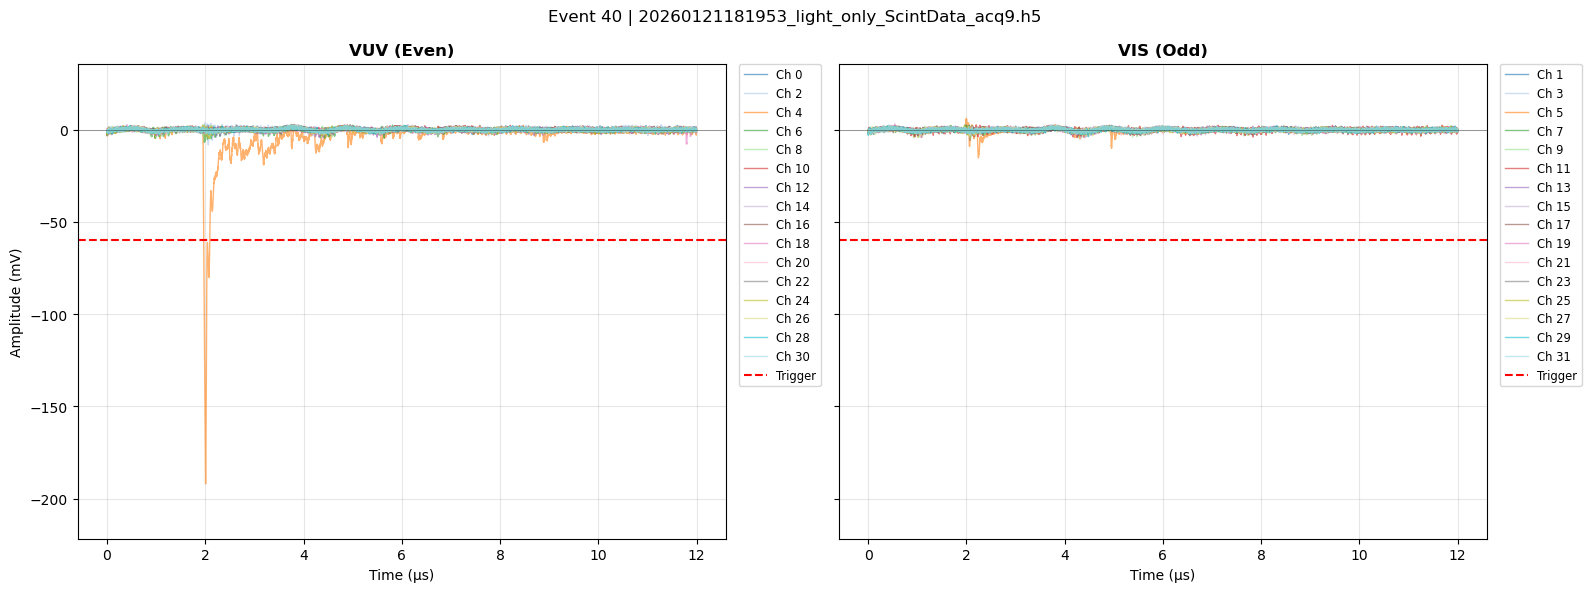

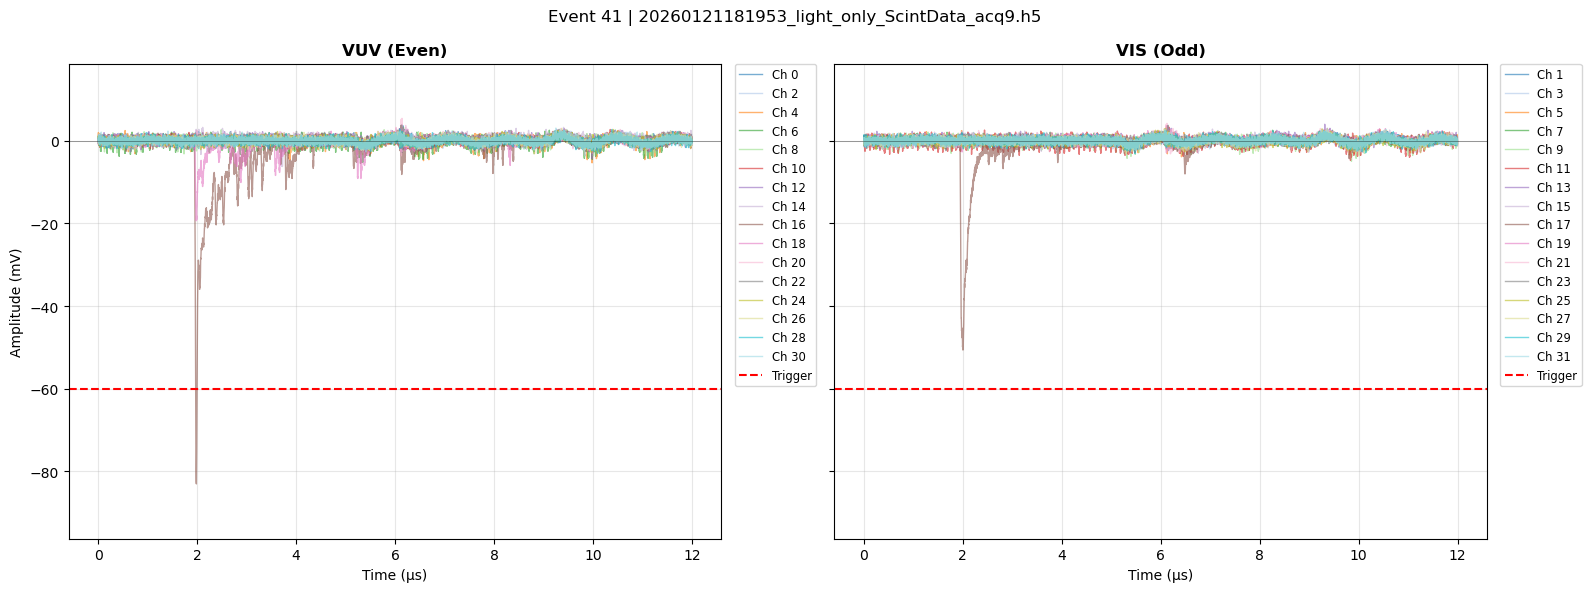

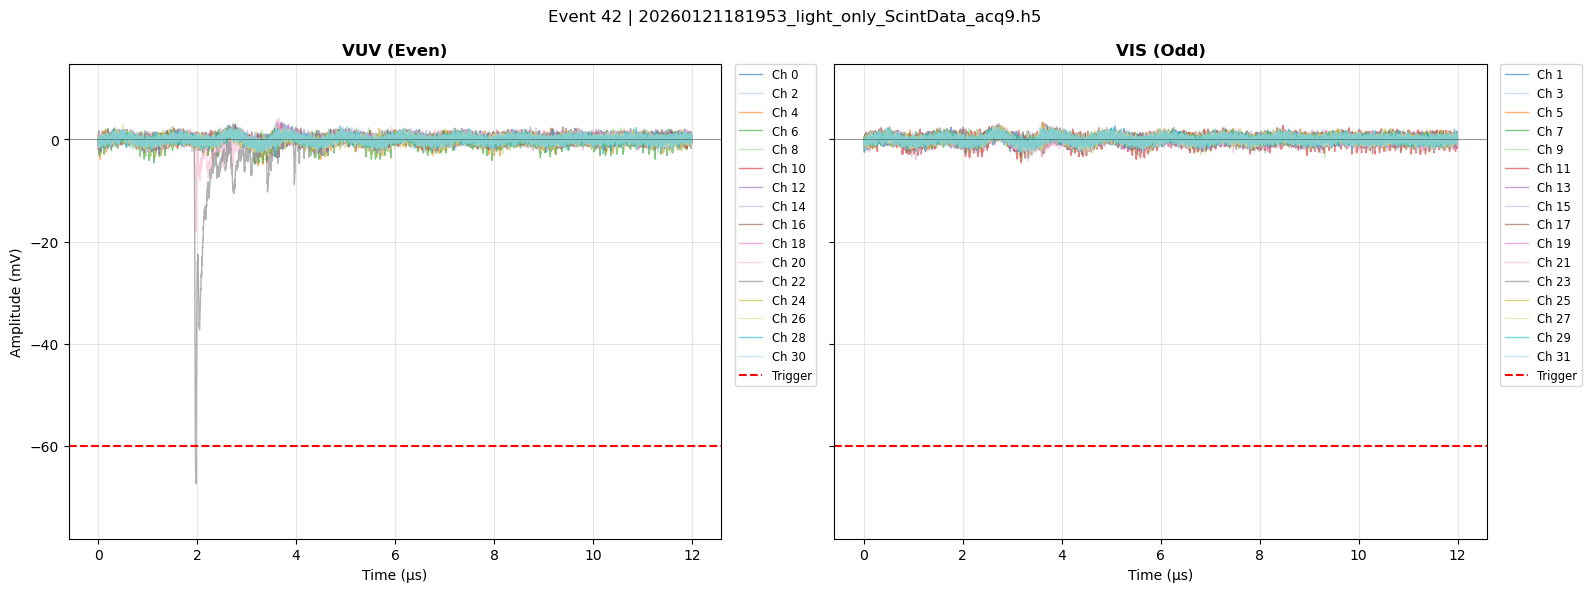

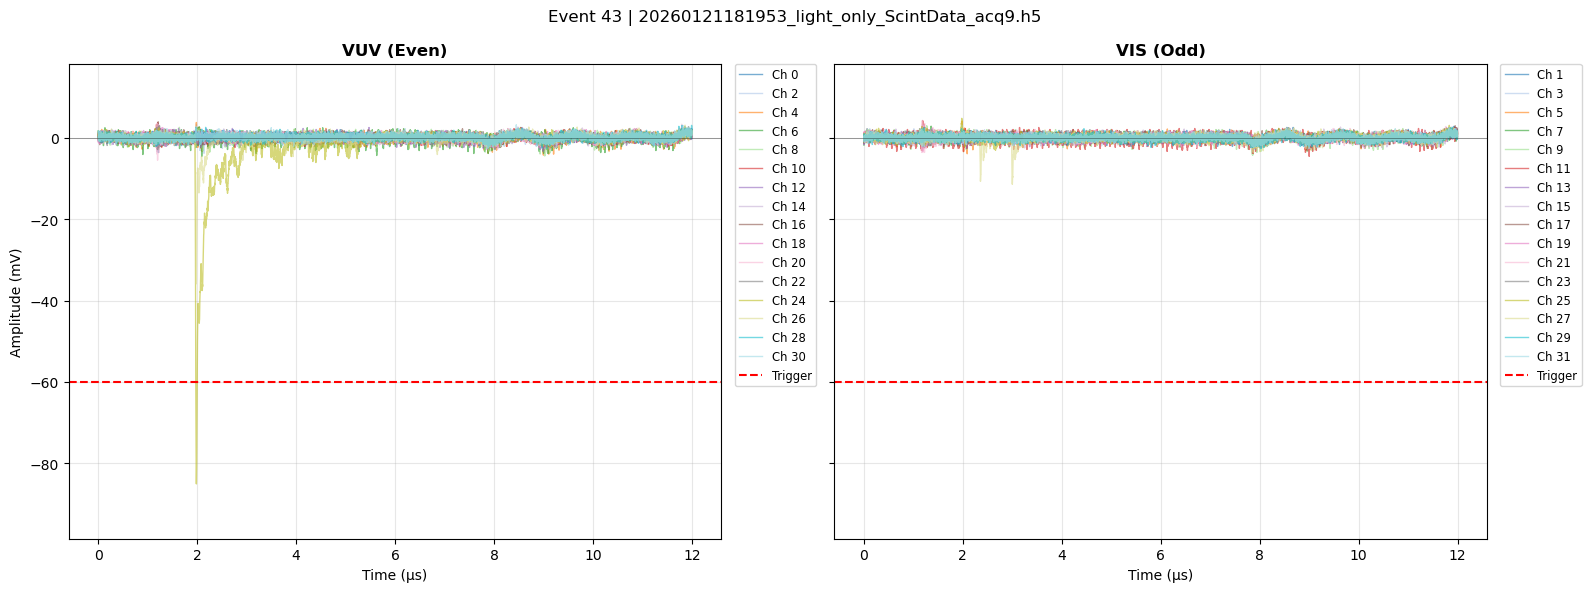

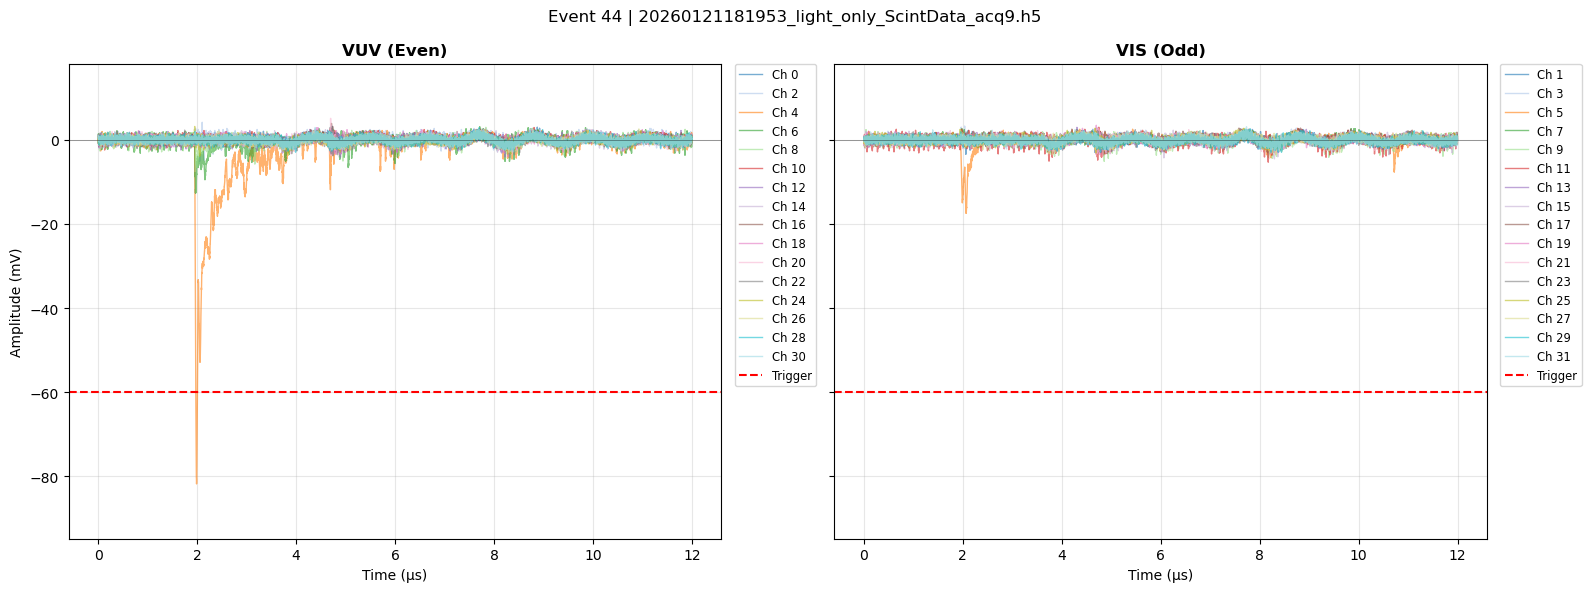

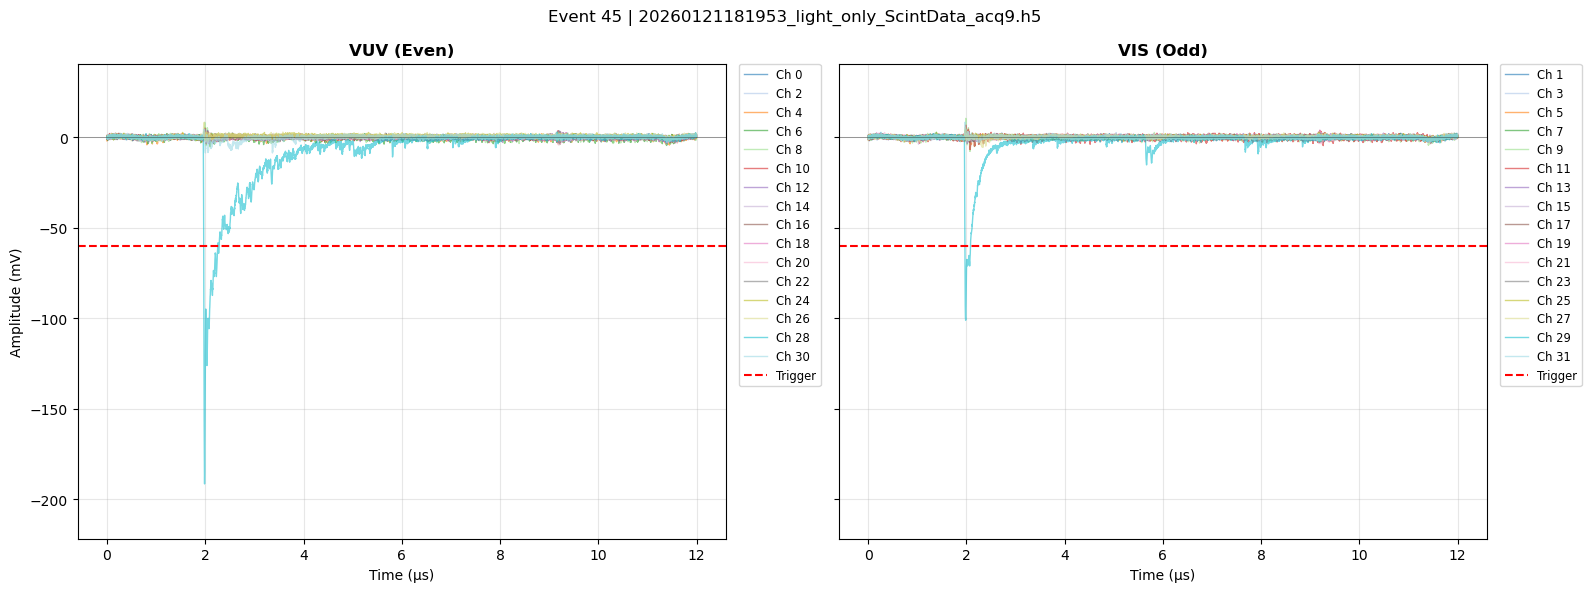

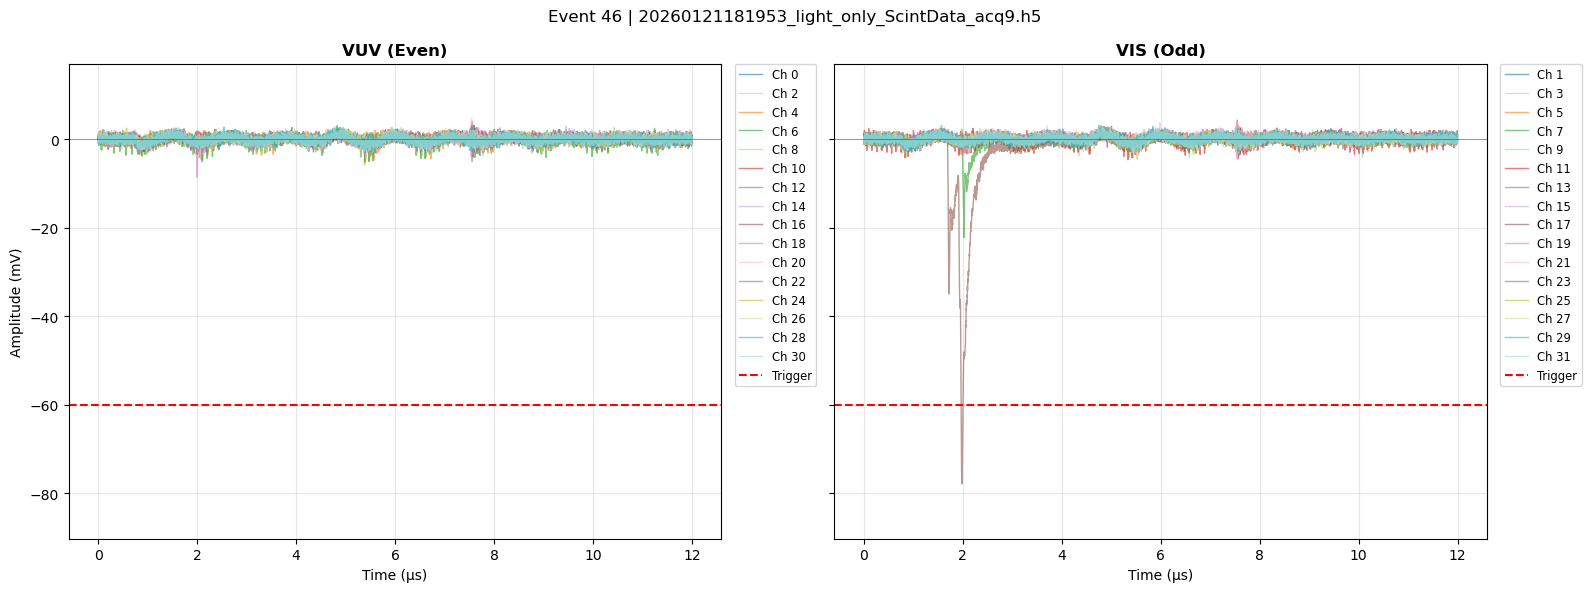

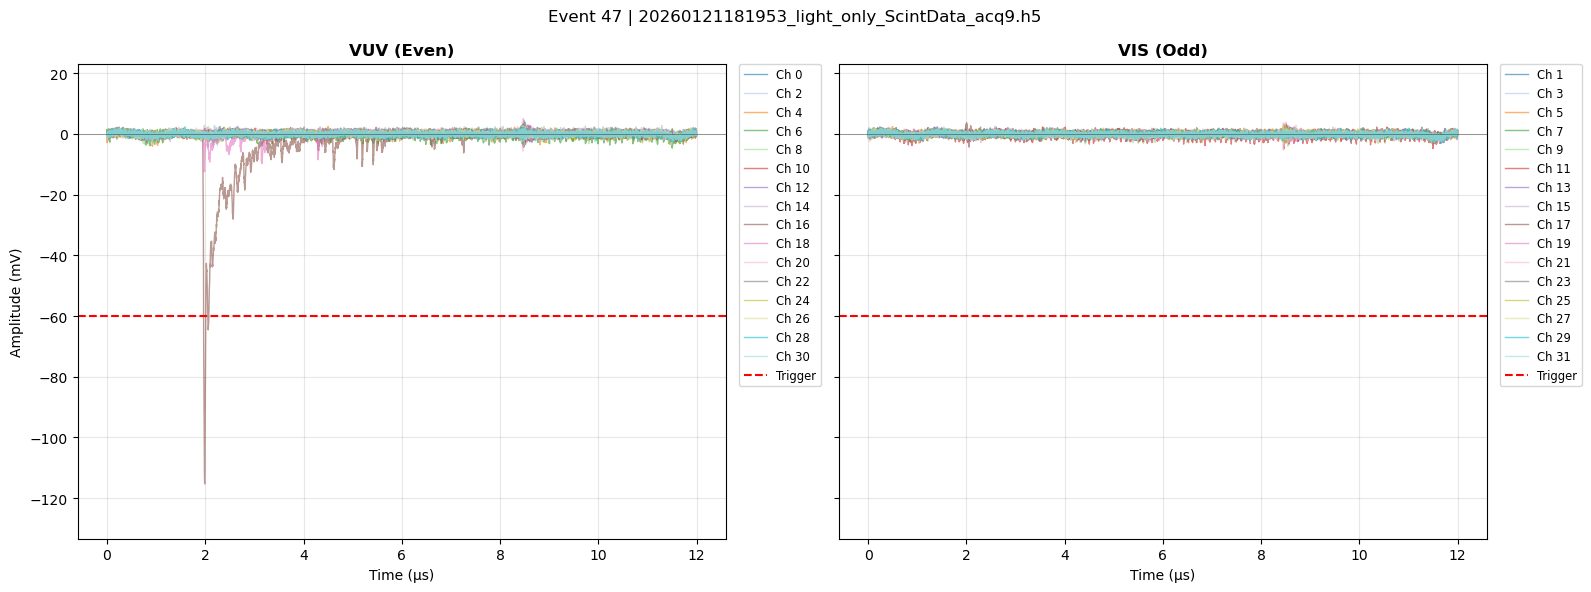

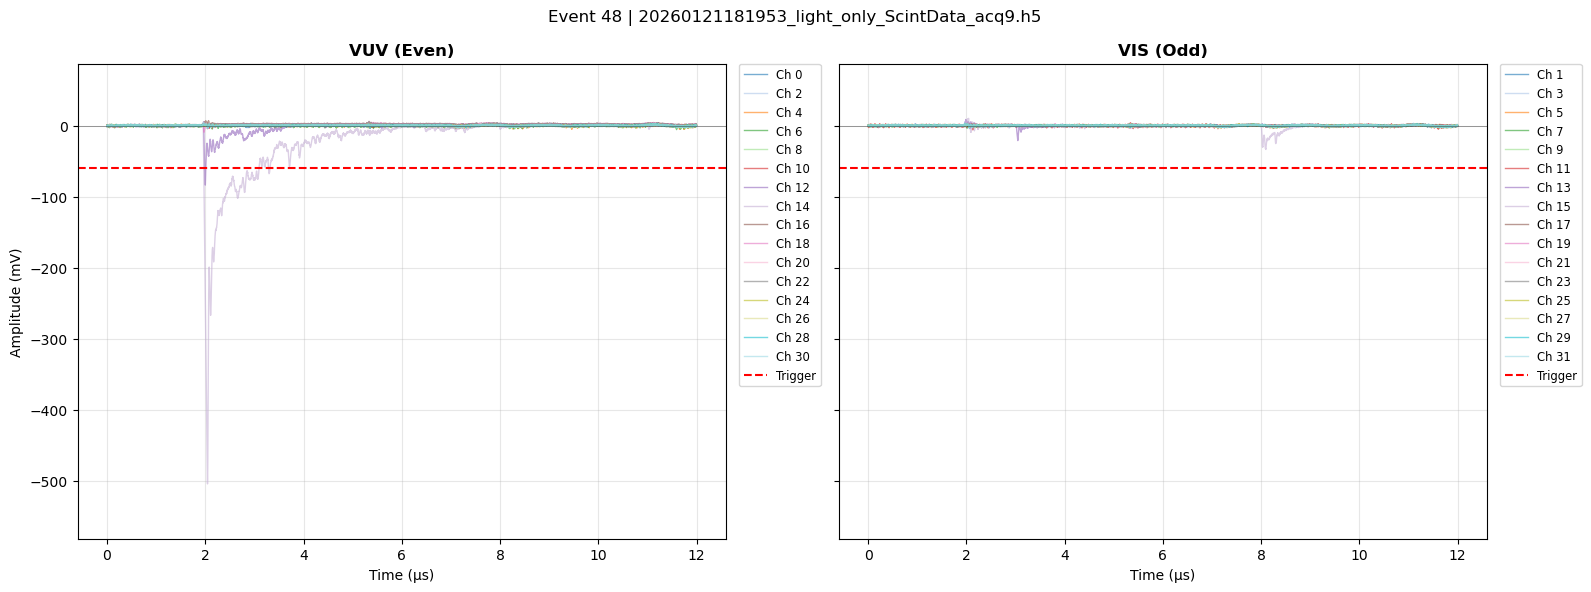

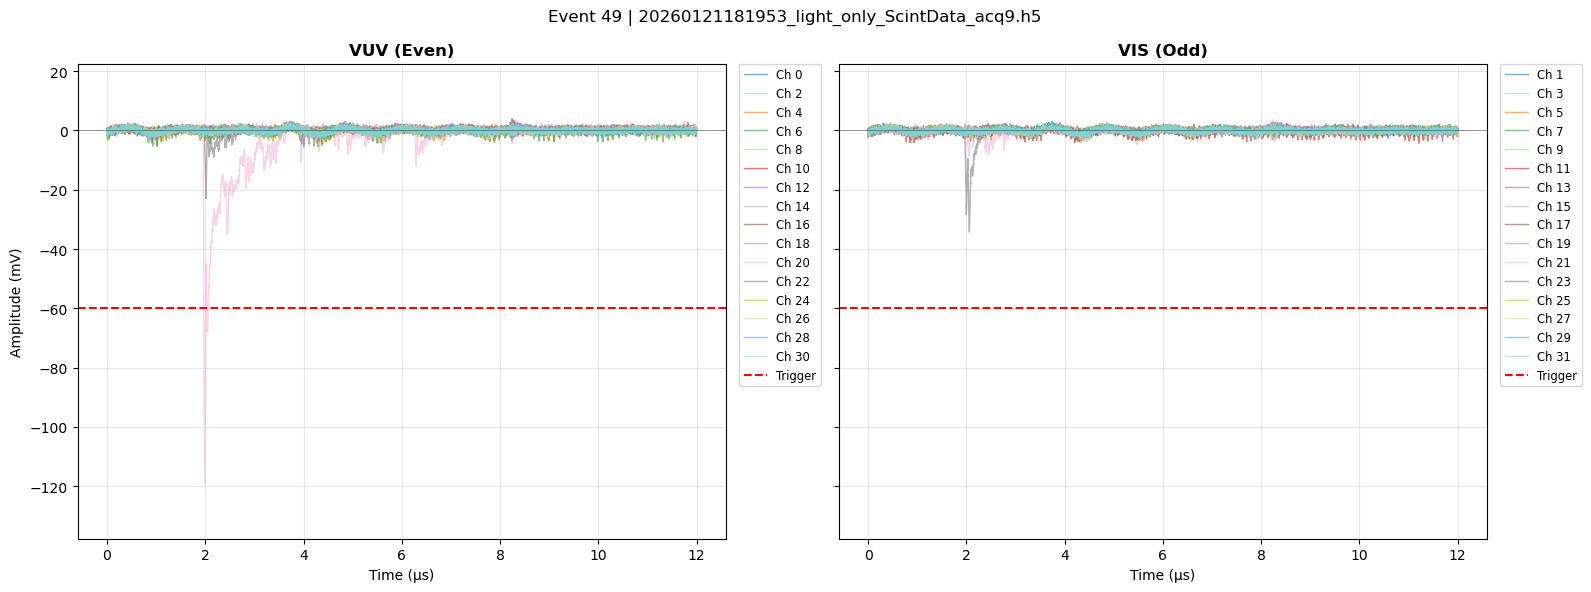

In [21]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
import detector_config as dc 

# --- 1. USER PARAMETERS ---
# Swap these lines to test the different behaviors
#target_file = "/NAS/Jon/pGRAMS_FlightBoardZ/Run7/PedestalData/acq4/20260121162129_light_only_PedestalData_acq4.h5"
#target_file = "/NAS/Jon/pGRAMS_FlightBoardZ/Run7/PedestalData/acq5/20260121162448_light_only_PedestalData_acq5.h5"
#target_file = "/NAS/Jon/pGRAMS_FlightBoardZ/Run7/PedestalData/acq6/20260121163522_light_only_PedestalData_acq6.h5"
target_file = "/NAS/Jon/pGRAMS_FlightBoardZ/Run7/ScintData/acq9/20260121181953_light_only_ScintData_acq9.h5"
# target_file = "./Run7/Pedestal_Data/acq0/YOUR_PEDESTAL_FILE.h5" 

events_to_plot = range(40, 50) 
trigger_thresh_mV = -60.0

# --- 2. LOAD ---
if not os.path.exists(target_file):
    print(f"[ERROR] File not found: {target_file}")
else:
    with h5py.File(target_file, 'r') as f:
        waveforms = f['waveforms_mV'][:]
        if 'baseline_mean_mV' in f:
            baselines = f['baseline_mean_mV'][:]
            print("Baselines applied.")
        else:
            baselines = np.zeros((waveforms.shape[0], waveforms.shape[1])) # Dummy 2D zeros
            print("[WARN] No baselines found.")

        run_config = f.attrs.get('run_config', 'light_only')
        res_ns = f.attrs.get('resolution_ns', 2)
        
        # TIME AXIS
        time_axis = np.arange(waveforms.shape[2]) * (res_ns * 1e-3)
        
        ch_map = dc.get_channel_map(run_config)
        
        filename = os.path.basename(target_file)
        
        # --- MODE DETECTION ---
        # Robust check: look for 'pedestal' in filename (case insensitive)
        is_pedestal = "pedestal" in filename.lower() and "sig" not in filename.lower()
        
        if "light-sig" in filename.lower() or "scint" in filename.lower():
            is_pedestal = False
        
        draw_trigger = not is_pedestal

        print(f"Plotting {filename}")
        print(f"Mode: {'PEDESTAL (Fixed Scale)' if is_pedestal else 'SCINTILLATION (Dynamic Scale)'}")
        print("-" * 60)

        # --- 3. PLOTTING LOOP ---
        for ev_idx in events_to_plot:
            if ev_idx >= waveforms.shape[0]: continue

            # --- CORRECTION: BROADCASTING ---
            # Waveforms[ev]: (32, 5000)
            # Baselines[ev]: (32,) -> reshape to (32, 1)
            # Result: (32, 5000)
            all_traces = waveforms[ev_idx] - baselines[ev_idx][:, np.newaxis]
            
            if is_pedestal:
                y_min, y_max = -10, 10
            else:
                # Dynamic limits for Scintillation
                raw_min = np.min(all_traces)
                raw_max = np.max(all_traces)
                
                # Calculate span and add 15% padding
                span = raw_max - raw_min
                if span == 0: span = 1 
                padding = span * 0.15
                
                y_min = raw_min - padding
                y_max = raw_max + padding
                
                if draw_trigger:
                    y_min = min(y_min, trigger_thresh_mV - 5)

            fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True, sharex=True)
            
            groups = [
                (axes[0], "VUV (Even)", ch_map["VUV"]),
                (axes[1], "VIS (Odd)",  ch_map["VIS"])
            ]
            
            for ax, label, channels in groups:
                if len(channels) > 0:
                    colors = cm.tab20(np.linspace(0, 1, len(channels)))
                
                for i, ch in enumerate(channels):
                    # --- SAME BROADCASTING LOGIC HERE IF NEEDED ---
                    # Or just direct subtraction since scalar subtraction works element-wise on 1D arrays
                    trace = waveforms[ev_idx, ch, :] - baselines[ev_idx, ch]
                    
                    ax.plot(time_axis, trace, color=colors[i], alpha=0.6, linewidth=1.0, 
                            label=f"Ch {ch}")
                
                if draw_trigger:
                    ax.axhline(trigger_thresh_mV, color='red', linestyle='--', linewidth=1.5, label="Trigger")

                ax.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)
                ax.set_title(label, fontweight='bold')
                ax.set_xlabel("Time (µs)")
                ax.grid(True, alpha=0.3)
                ax.set_ylim(y_min, y_max)
                
                ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0, fontsize='small', ncol=1)

            axes[0].set_ylabel("Amplitude (mV)")
            plt.suptitle(f"Event {ev_idx} | {filename}", fontsize=12, y=0.98)
            plt.tight_layout()
            plt.show()

Target Acquired: 20260121181953_light_only_ScintData_acq9.h5
Configuration Detected: LIGHT_ONLY
Processing 100 events...
Computing Per-Channel Averages...
Generating Visuals...


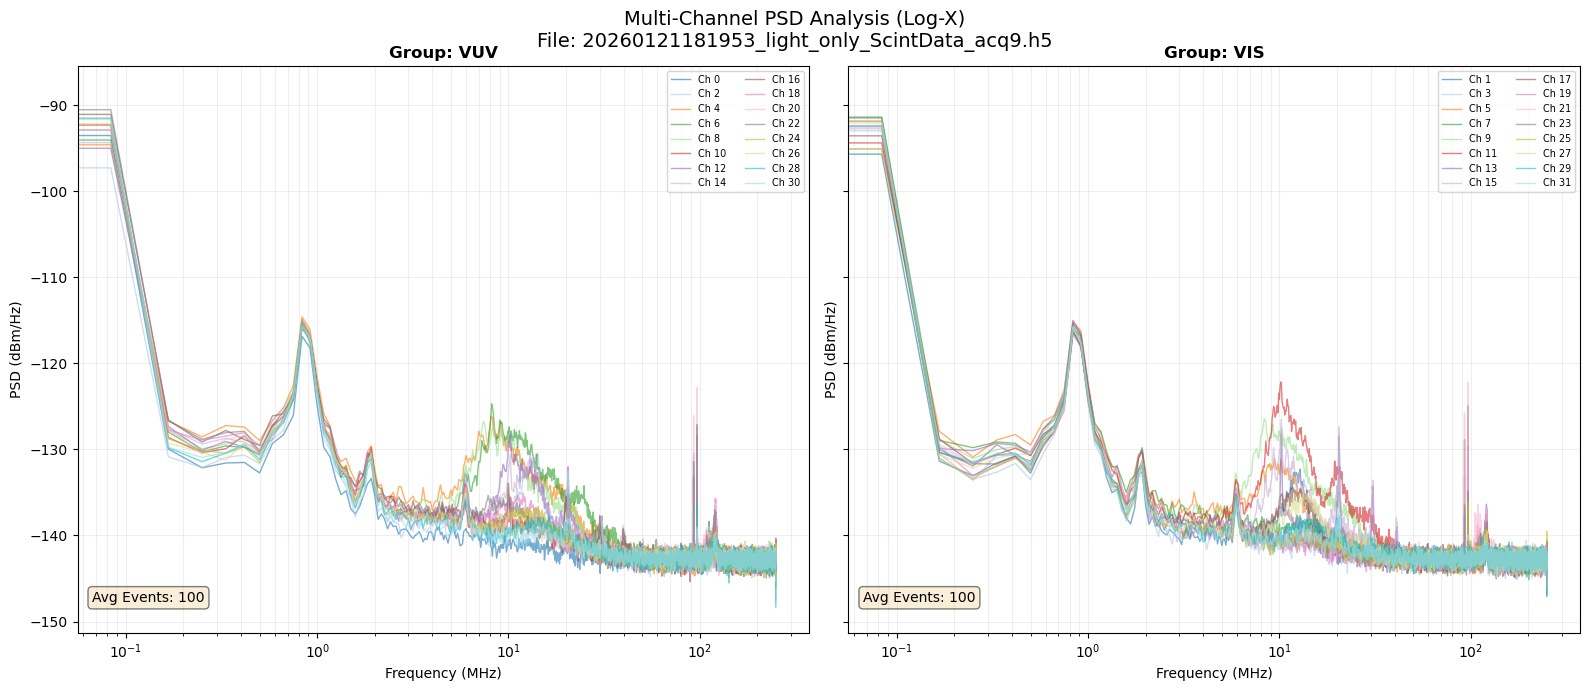

: 

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
import grams_tools as gt  # Assumes updated library from previous interaction
import detector_config as dc #

# --- CONFIGURATION ---
TARGET_FILE = "/NAS/Jon/pGRAMS_FlightBoardZ/Run7/ScintData/acq9/20260121181953_light_only_ScintData_acq9.h5"
EVENTS_TO_PROCESS = 100 

# --- UTILITY: DETECT CONFIG ---
def detect_config(h5_file, filename):
    if 'run_config' in h5_file.attrs:
        cfg = h5_file.attrs['run_config']
        if 'combo' in cfg.lower(): return 'combo'
        if 'light' in cfg.lower(): return 'light_only'
    
    fname_lower = filename.lower()
    if 'combo' in fname_lower: return 'combo'
    return 'light_only'

# --- MAIN EXECUTION ---
if not os.path.exists(TARGET_FILE):
    print(f"[ERR] Target not found: {TARGET_FILE}")
else:
    print(f"Target Acquired: {os.path.basename(TARGET_FILE)}")
    
    # Structure: { channel_id: [list of psd_arrays] }
    # We store per-channel now, not per-group
    channel_data = {}
    freq_axis_mhz = None
    
    with h5py.File(TARGET_FILE, 'r') as f:
        config_mode = detect_config(f, os.path.basename(TARGET_FILE))
        print(f"Configuration Detected: {config_mode.upper()}")
        
        res_ns = f.attrs.get('resolution_ns', 2) 
        n_events = f['waveforms_mV'].shape[0]
        limit = min(n_events, EVENTS_TO_PROCESS)
        
        ch_map = dc.get_channel_map(config_mode)
        
        print(f"Processing {limit} events...")
        
        for i in range(limit):
            waveforms = f['waveforms_mV'][i]
            
            # Initialize Frequency Axis Once
            if freq_axis_mhz is None:
                n_samples = waveforms.shape[1]
                freq_axis = gt.get_freq_axis(n_samples, res_ns)
                freq_axis_mhz = freq_axis / 1e6 
            
            # Process all active channels in the map
            all_active_chs = []
            for group in ch_map.values():
                all_active_chs.extend(group)
                
            for ch_idx in all_active_chs:
                if ch_idx not in channel_data:
                    channel_data[ch_idx] = []
                    
                trace = waveforms[ch_idx]
                
                # Math from grams_tools
                psd_dbm = gt.compute_psd_trace(trace, res_ns, window_type='hanning')
                channel_data[ch_idx].append(psd_dbm)

    # --- AGGREGATION ---
    print("Computing Per-Channel Averages...")
    avg_psd_per_ch = {}
    for ch, trace_list in channel_data.items():
        if trace_list:
            # Average the dBm traces for this specific channel
            stack = np.vstack(trace_list)
            avg_psd_per_ch[ch] = np.mean(stack, axis=0)

    # --- PLOTTING ---
    print("Generating Visuals...")
    
    # Setup Layout
    if config_mode == 'combo':
        fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=True, sharey=True)
        layout = [
            (axes[0, 0], 'VUV', ch_map['VUV']),
            (axes[0, 1], 'VIS', ch_map['VIS']),
            # Split Charge into X (24-27) and Y (28-31) for better visibility if desired
            # or just dump all charge into one plot. Let's follow MassPlotter style
            (axes[1, 0], 'Charge X', [c for c in ch_map['Charge'] if 24 <= c <= 27]),
            (axes[1, 1], 'Charge Y', [c for c in ch_map['Charge'] if 28 <= c <= 31]),
        ]
    else:
        fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
        layout = [
            (axes[0], 'VUV', ch_map['VUV']),
            (axes[1], 'VIS', ch_map['VIS'])
        ]

    # Render Loops
    cmap = plt.get_cmap('tab20') #
    
    for ax, title, channels in layout:
        if not channels:
            ax.text(0.5, 0.5, "No Channels", ha='center', transform=ax.transAxes)
            continue
            
        # Color cycler for this subplot
        colors = cmap(np.linspace(0, 1, len(channels)))
        
        for i, ch in enumerate(channels):
            if ch in avg_psd_per_ch:
                # PLOT: Log X (semilogx), Linear Y (dBm is already log power)
                ax.semilogx(freq_axis_mhz, avg_psd_per_ch[ch], 
                            color=colors[i], 
                            alpha=0.6,    # Transparency requested
                            linewidth=1.0, 
                            label=f"Ch {ch}")

        ax.set_title(f"Group: {title}", fontweight='bold')
        ax.set_xlabel("Frequency (MHz)")
        ax.set_ylabel("PSD (dBm/Hz)")
        ax.grid(True, which="both", ls="-", alpha=0.2)
        
        # Legend
        ax.legend(fontsize='x-small', ncol=2, loc='upper right')
        
        # Info Box (Bottom Left to avoid legends usually)
        info_text = f"Avg Events: {limit}"
        props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
        ax.text(0.02, 0.05, info_text, transform=ax.transAxes, fontsize=10,
                verticalalignment='bottom', bbox=props)

    plt.suptitle(f"Multi-Channel PSD Analysis (Log-X)\nFile: {os.path.basename(TARGET_FILE)}", fontsize=14)
    plt.tight_layout()
    plt.subplots_adjust(top=0.90)
    plt.show()